### Prospectivity Map

####  *AUTHOR:* Ehsan Farahbakhsh
####  *CONTACT:* e.farahbakhsh@sydney.edu.au
####  *DATE last modified:* 05/08/2025

In [1]:
from ipywidgets import interact
import os

import cartopy.crs as ccrs
import cmcrameri.cm as ccm
import gplately
import joblib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.kernel_ridge import KernelRidge
from tqdm import tqdm

from lib.prospectivity_map import *
from lib.feature_extraction import *
from lib.reconstruction_coregistration import *
from lib.predictive_modelling import *
from lib.plot import *

from parameters import parameters

In [2]:
# Timespan for analysis
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"]
time_max = parameters["timespan"]["max"]
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

buffer_distance = parameters["buffer_distance"]
grid_resolution = parameters["grid_resolution"]

plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
buffer_zones_dir = parameters["buffer_zones_dir"]
ml_dir = parameters["ml_dir"]
coastline_prob_grids_dir = parameters["coastline_prob_grids_dir"]
coastline_entropy_grids_dir = parameters["coastline_entropy_grids_dir"]
coastline_vote_variance_grids_dir = parameters["coastline_vote_variance_grids_dir"]
coastline_prob_maps_dir = parameters["coastline_prob_maps_dir"]
coastline_entropy_maps_dir = parameters["coastline_entropy_maps_dir"]
coastline_vote_variance_maps_dir = parameters["coastline_vote_variance_maps_dir"]

subduction_data_filename = parameters["subduction_data_filename"]
coastlines_filename = parameters["coastlines_filename"]
coastline_coords_filename = parameters["coastline_coords_filename"]
coastline_data_filename = parameters["coastline_data_filename"]
coastline_prob_filename = parameters["coastline_prob_filename"]
deposit_coords_recon_all_filename = parameters["deposit_coords_recon_all_filename"]
coastline_prob_present_day_filename = parameters["coastline_prob_present_day_filename"]
coastline_prob_present_day_grid_filename = parameters["coastline_prob_present_day_grid_filename"]
coastline_entropy_present_day_grid_filename = parameters["coastline_entropy_present_day_grid_filename"]
coastline_vote_variance_present_day_grid_filename = parameters["coastline_vote_variance_present_day_grid_filename"]
deposit_coords_recon_filename = parameters["deposit_coords_recon_filename"]

model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]
robust_scaler_filename = parameters["robust_scaler_filename"]

ml_dir = os.path.join(outputs_dir, ml_dir)
buffer_zones_dir = os.path.join(outputs_dir, buffer_zones_dir)
coastline_prob_grids_dir = os.path.join(ml_dir, coastline_prob_grids_dir)
coastline_entropy_grids_dir = os.path.join(ml_dir, coastline_entropy_grids_dir)
coastline_vote_variance_grids_dir = os.path.join(ml_dir, coastline_vote_variance_grids_dir)
coastline_prob_maps_dir = os.path.join(ml_dir, coastline_prob_maps_dir)
coastline_entropy_maps_dir = os.path.join(ml_dir, coastline_entropy_maps_dir)
coastline_vote_variance_maps_dir = os.path.join(ml_dir, coastline_vote_variance_maps_dir)

subduction_data_filename = os.path.join(outputs_dir, subduction_data_filename)
coastlines_filename = os.path.join(inputs_dir, coastlines_filename)
coastline_coords_filename = os.path.join(outputs_dir, coastline_coords_filename)
coastline_data_filename = os.path.join(outputs_dir, coastline_data_filename)
coastline_prob_filename = os.path.join(ml_dir, coastline_prob_filename)
deposit_coords_recon_all_filename = os.path.join(outputs_dir, deposit_coords_recon_all_filename)
coastline_prob_present_day_filename = os.path.join(ml_dir, coastline_prob_present_day_filename)
coastline_prob_present_day_grid_filename = os.path.join(ml_dir, coastline_prob_present_day_grid_filename)
coastline_entropy_present_day_grid_filename = os.path.join(ml_dir, coastline_entropy_present_day_grid_filename)
coastline_vote_variance_present_day_grid_filename = os.path.join(ml_dir, coastline_vote_variance_present_day_grid_filename)
deposit_coords_recon_filename = os.path.join(outputs_dir, deposit_coords_recon_filename)

model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)
robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)

agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")
crusthick_dir = os.path.join(inputs_dir, "CrustalThickness")

n_jobs = 10

In [3]:
# shirmard25
rotation_model = [
    plate_model_dir+"/1800_1000_rotfile_20240725.rot",
    plate_model_dir+"/1000_0_rotfile_20240725.rot",
]

topology_features = [
    plate_model_dir+"/1800-1000_plate_boundaries.gpml",
    plate_model_dir+"/250-0_plate_boundaries.gpml",
    plate_model_dir+"/410-250_plate_boundaries.gpml",
    plate_model_dir+"/1000-410-Convergence.gpml",
    plate_model_dir+"/1000-410-Divergence.gpml",
    plate_model_dir+"/1000-410-plate-boundaries.gpml",
    plate_model_dir+"/1000-410-Transforms.gpml",
    plate_model_dir+"/TopologyBuildingBlocks.gpml",
]

static_polygons = plate_model_dir+"/static_polygons.gpmlz"
coastlines = plate_model_dir+"/shapes_coasts.gpmlz"
continents = plate_model_dir+"/shapes_continents.gpmlz"
COBs = plate_model_dir+"/COBfile_1800_0.gpml"

plate_reconstruction = PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=topology_features,
    static_polygons=static_polygons,
)

gplot = PlotTopologies(
    plate_reconstruction=plate_reconstruction,
    coastlines=coastlines,
    continents=continents,
    COBs=COBs,
)

projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

### Points within Continental Landmass

In [4]:
if os.path.isfile(coastline_coords_filename):
    coastline_coords = pd.read_csv(coastline_coords_filename)
else:
    coastline_coords = reconstruct_coastline_nodes(
        coastlines=coastlines_filename,
        resolution=grid_resolution,
        polygons_dir=buffer_zones_dir,
        time_steps=time_steps,
        plate_reconstruction=plate_reconstruction,
        output_filename=coastline_coords_filename,
        verbose=True,
    )

In [5]:
@interact
def show_map(time=time_steps):
    gplot.time = time    
    
    agegrid_filename =  f"seafloor_age_{time}Ma.nc"
    agegrid_file = os.path.join(agegrid_dir, agegrid_filename)    
    agegrid = gplately.grids.read_netcdf_grid(agegrid_file)
    
    fig = plt.figure(figsize=(16, 12))
    ax = plt.axes(
        projection=projection,
        facecolor=(plt.cm.colors.to_rgba("darkgray", alpha=0.5))
    )

    im = gplot.plot_grid(ax, agegrid.data, cmap=ccm.lapaz_r, vmin=0, vmax=230, alpha=0.7, zorder=1)

    gplot.plot_coastlines(ax, facecolor="darkgray", edgecolor="none", zorder=2)
    gplot.plot_plate_motion_vectors(ax, spacingX=10, spacingY=10, normalise=True, alpha=0.1, zorder=3)

    # buffer_zones_t_filename = f"buffer_zones_{time}Ma.geojson"
    # buffer_zones_t_filename = os.path.join(buffer_zones_dir, buffer_zones_t_filename)
    # buffer_zones_t = gpd.read_file(buffer_zones_t_filename)

    # buffer_zones_t.plot(
    #     ax=ax,
    #     transform=ccrs.PlateCarree(),
    #     facecolor="palegreen",
    #     edgecolor="none",
    #     alpha=0.7,
    #     zorder=4,
    # )

    coastline_coords_t = coastline_coords[coastline_coords["age (Ma)"] == time]

    gplot.plot_ridges(ax, color="dimgray", linewidth=1.5, zorder=5)
    gplot.plot_transforms(ax, color="dimgray", linewidth=1.5, zorder=5)

    ax.scatter(
        coastline_coords_t["lon"],
        coastline_coords_t["lat"],
        transform=ccrs.PlateCarree(),
        marker=".",
        c="red",
        s=1,
        alpha=0.5,
        zorder=6
    )
    
    gplot.plot_trenches(ax, color="k", alpha=0.3, zorder=7)
    gplot.plot_subduction_teeth(ax, spacing=0.05, color="k", alpha=0.3, zorder=8)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, linewidth=1, color="gray", alpha=0.3, linestyle="--", zorder=9)

    ax.text(0.49,-0.03, "60°E", transform=ax.transAxes, fontsize=16)
    ax.text(0.46,-0.03, "0°", transform=ax.transAxes, fontsize=16)
    ax.text(0.40,-0.025, "60°W", transform=ax.transAxes, fontsize=16)
    
    gl.top_labels=False
    gl.bottom_labels=False
    
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}
    
    cb = fig.colorbar(im, orientation="horizontal", shrink=0.4, pad=0.06, extend="max")
    cb.set_label("Seafloor Age (Ma)", fontsize=16, labelpad=10)
    cb.set_ticks([0, 50, 100, 150, 200])
    cb.ax.tick_params(labelsize=16)

    # Dummy handle to trigger custom handler
    trench_handle = Line2D([], [], color="black")
    
    # Add custom handles
    custom_handles = [
        Patch(facecolor="darkgray", edgecolor="none"),
        # Patch(facecolor="palegreen", edgecolor="none", alpha=0.7),
        trench_handle,
        Line2D([0], [0], color="dimgray", lw=2),
        Line2D([0], [0], marker=".", markerfacecolor="red", markeredgecolor="none", markersize=10, linestyle="None")
    ]
    custom_labels = [
        "Continental Crust",
        # "Target Back-Arc Envs",
        "Trench Lines",
        "Mid-Ocean Ridges/\nTransform Faults",
        "Target Points within\nBack-Arc Envs and\nContinental Landmass",
    ]

    # Draw legend
    ax.legend(custom_handles, custom_labels, fontsize=16, loc="lower left", bbox_to_anchor=(0, -0.3),
              handler_map={trench_handle: HandlerTrenchLine()})

    ax.set_title(f"{time} Ma", fontsize=25, y=1.04)
        
    plt.show()

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

### Coregistration

In [6]:
if os.path.isfile(coastline_data_filename):
    coastline_data = pd.read_csv(coastline_data_filename)
else:
    subduction_data = pd.read_csv(subduction_data_filename)
    
    coastline_data = run_coregister_point_data(
        point_data=coastline_coords,
        subduction_data=subduction_data,
        keep_index=True,
        n_jobs=n_jobs,
        verbose=True,
    )
    
    coastline_data = run_coregister_crustal_thickness(
        point_data=coastline_data,
        input_dir=crusthick_dir,
        output_filename=coastline_data_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

### Calculate Probability, Entropy, and Vote Variance

In [7]:
if os.path.isfile(coastline_prob_filename):
    print(f"Probabilities have already been calculated and saved in {coastline_prob_filename}\nLoading ...")
    coastline_prob = pd.read_csv(coastline_prob_filename)
else:
    # Load model and scaler
    model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
    model_rf_calibrated.n_jobs = n_jobs
    robust_scaler = joblib.load(robust_scaler_filename)

    if "valid" in coastline_data.columns:
        # Filter valid rows
        coastline_data = coastline_data[coastline_data["valid"]].copy()

    # Scale the features
    selected_features = model_rf_calibrated.feature_names_in_
    coastline_scaled = robust_scaler.transform(coastline_data[selected_features])
    coastline_scaled = pd.DataFrame(coastline_scaled, columns=selected_features)

    # Predict probabilities
    probs = model_rf_calibrated.predict_proba(coastline_scaled)[:, 1].ravel()

    # Prepare final DataFrame
    columns_prob = [
        "index",
        "lon",
        "lat",
        "present_lon",
        "present_lat",
        "age (Ma)",
    ]
    
    coastline_prob = coastline_data[columns_prob].copy()
    coastline_prob["probability"] = probs

    # Calculate metrics
    entropies = calculate_entropy(probs)
    coastline_prob["entropy"] = entropies
    
    # vote_variances = calculate_tree_vote_variance(
    #     model_rf_calibrated.estimator,
    #     coastline_scaled.values,
    #     n_jobs=n_jobs,
    # )

    chunk_size = 100000  # Adjust based on available memory
    n_samples = coastline_scaled.shape[0]
    n_chunks = (n_samples // chunk_size) + (1 if n_samples % chunk_size != 0 else 0)  # Ensure last chunk is included
    
    for i in tqdm(range(n_chunks)):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, n_samples)
    
        X_chunk = coastline_scaled.iloc[start_idx:end_idx]
        
        # Calculate vote variance for the chunk
        vote_variances_chunk = calculate_tree_vote_variance(model_rf_calibrated.estimator, X_chunk.values)
        
        # Ensure that the chunk size matches the number of rows being processed
        if len(vote_variances_chunk) != (end_idx - start_idx):
            raise ValueError(f"Mismatch in size: {len(vote_variances_chunk)} vs. {end_idx - start_idx}")
        
        # Assign the result to the appropriate slice of the dataframe
        coastline_prob.loc[start_idx:end_idx-1, "vote_variance"] = vote_variances_chunk
    
    # Export rows with calculated metrics
    print(f"Saving the metrics as a CSV file: {coastline_prob_filename}")
    coastline_prob.to_csv(coastline_prob_filename, index=False)

if os.path.exists(coastline_prob_grids_dir):
    print(f"Probability grids are located in {coastline_prob_grids_dir}")
else:
    os.makedirs(coastline_prob_grids_dir, exist_ok=True)

    create_grids(
        data=coastline_prob_filename,
        output_dir=coastline_prob_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="probability",
        filename_format="coastline_probability_grid_{}Ma.nc",
    )


if os.path.exists(coastline_entropy_grids_dir):
    print(f"Entropy grids are located in {coastline_entropy_grids_dir}")
else:
    os.makedirs(coastline_entropy_grids_dir, exist_ok=True)

    create_grids(
        data=coastline_prob_filename,
        output_dir=coastline_entropy_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="entropy",
        filename_format="coastline_entropy_grid_{}Ma.nc",
    )


if os.path.exists(coastline_vote_variance_grids_dir):
    print(f"Vote variance grids are located in {coastline_vote_variance_grids_dir}")
else:
    os.makedirs(coastline_vote_variance_grids_dir, exist_ok=True)

    create_grids(
        data=coastline_prob_filename,
        output_dir=coastline_vote_variance_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="vote_variance",
        filename_format="coastline_vote_variance_grid_{}Ma.nc",        
    )

Probabilities have already been calculated and saved in outputs\ml\coastline_prob.csv
Loading ...
Probability grids are located in outputs\ml\coastline_prob_grids
Entropy grids are located in outputs\ml\coastline_entropy_grids
Vote variance grids are located in outputs\ml\coastline_vote_variance_grids


### Probability Maps

In [8]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_prob_grids_dir,
            f"coastline_probability_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="probability",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_coords_recon_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [9]:
if os.path.exists(coastline_prob_maps_dir):
    print(f"Probability maps are located in {coastline_prob_maps_dir}")
else:
    os.makedirs(coastline_prob_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_prob_maps_dir, f"coastline_probability_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_prob_grids_dir,
                    f"coastline_probability_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_probability_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Probability maps are located in outputs\ml\coastline_prob_maps


### Entropy Maps

In [10]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_entropy_grids_dir,
            f"coastline_entropy_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="entropy",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_coords_recon_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [11]:
if os.path.exists(coastline_entropy_maps_dir):
    print(f"Entropy maps are located in {coastline_entropy_maps_dir}")
else:
    os.makedirs(coastline_entropy_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_entropy_maps_dir, f"coastline_entropy_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_entropy_grids_dir,
                    f"coastline_entropy_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="entropy",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_entropy_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Entropy maps are located in outputs\ml\coastline_entropy_maps


### Vote Variance Maps

In [12]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_vote_variance_grids_dir,
            f"coastline_vote_variance_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="vote variance",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_coords_recon_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [13]:
if os.path.exists(coastline_vote_variance_maps_dir):
    print(f"Vote variance maps are located in {coastline_vote_variance_maps_dir}")
else:
    os.makedirs(coastline_vote_variance_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=16,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // 16) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_vote_variance_maps_dir, f"coastline_vote_variance_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_vote_variance_grids_dir,
                    f"coastline_vote_variance_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="vote variance",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_vote_variance_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Vote variance maps are located in outputs\ml\coastline_vote_variance_maps


### Global Prospectivity Map of Porphyry Mineralisation

In [14]:
if os.path.isfile(coastline_prob_present_day_filename):
    coastline_prob_present_day = pd.read_csv(coastline_prob_present_day_filename)
else:
    coastline_prob_high = coastline_prob[coastline_prob["probability"] > 0.5]
    coastline_prob_high_mean = coastline_prob_high.groupby("index")[["probability", "entropy", "vote_variance"]].mean().reset_index()
    present_day_coords = coastline_data[["index", "present_lon", "present_lat"]].drop_duplicates(subset="index")
    coastline_prob_present_day = pd.merge(coastline_prob_high_mean, present_day_coords, on="index", how="left")
    coastline_prob_present_day = coastline_prob_present_day[["index", "present_lon", "present_lat", "probability", "entropy", "vote_variance"]]
    coastline_prob_present_day.to_csv(coastline_prob_present_day_filename, index=False)

In [15]:
model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
selected_features = model_rf_calibrated.feature_names_in_

deposit_coords_recon = pd.read_csv(deposit_coords_recon_filename)

coastline_prob_mean_age = coastline_prob.groupby("age (Ma)")["probability"].mean().reset_index()
coastline_prob_std_age = coastline_prob.groupby("age (Ma)")["probability"].std().reset_index()

# Sort by age to ensure correct ordering
coastline_prob_mean_age = coastline_prob_mean_age.sort_values("age (Ma)")
coastline_prob_std_age = coastline_prob_std_age.sort_values("age (Ma)")

# Define input and target
ages = coastline_prob_mean_age["age (Ma)"].values.reshape(-1, 1)
probs = coastline_prob_mean_age["probability"].values.reshape(-1, 1)
probs_std = coastline_prob_std_age["probability"].values.reshape(-1, 1)

ages_smooth, probs_smooth = smooth_curve(ages, probs)
_, probs_std_smooth = smooth_curve(ages, probs_std)

coastline_data = pd.read_csv(coastline_data_filename)

@interact
def show_map(feature=selected_features):
    coastline_feat_age = coastline_prob.merge(coastline_data[["index", "age (Ma)", feature]], on=["index", "age (Ma)"], how="left")
    
    coastline_feat_mean_age = coastline_feat_age.groupby("age (Ma)")[feature].mean().reset_index()
    coastline_feat_std_age = coastline_feat_age.groupby("age (Ma)")[feature].std().reset_index()
    
    coastline_feat_mean_age = coastline_feat_mean_age.sort_values("age (Ma)")
    coastline_feat_std_age = coastline_feat_std_age.sort_values("age (Ma)")
    
    feats = coastline_feat_mean_age[feature].values.reshape(-1, 1)
    feats_std = coastline_feat_std_age[feature].values.reshape(-1, 1)
    
    _, feats_smooth = smooth_curve(ages, feats)
    _, feats_std_smooth = smooth_curve(ages, feats_std)
    
    # Set up plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_facecolor("whitesmoke")
    
    # Plot histogram
    ax1.hist(deposit_coords_recon["age (Ma)"], bins=40, orientation="vertical", color="LightSalmon", alpha=0.5, edgecolor="gray", zorder=1)
    ax1.set_ylabel("Deposit count")

    # Create secondary y-axis
    ax2 = ax1.twinx()
    
    # Plot smoothed probability line
    ax2.plot(ages_smooth, probs_smooth, color="orangered", linewidth=2, label="Mineralisation probability", zorder=2)
#     ax2.fill_between(ages_smooth.flatten(),
#                  (probs_smooth - probs_std_smooth).flatten(),
#                  (probs_smooth + probs_std_smooth).flatten(),
#                  color="orangered", alpha=0.2)
    
#     ax2.plot(ages, probs, color="orangered", linewidth=2, label="Mineralisation probability")

    ax2.set_xlim(time_max, 0)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Age (Ma)")
    ax2.set_ylabel("Mean probability")
    # ax2.set_title("Mean Probability and Deposit Frequency by Age")    
    
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))  # shift third axis to the right
    ax3.plot(ages_smooth, feats_smooth,
             linestyle="-", color="royalblue", label=format_feature_name(feature), zorder=2)
#     ax3.fill_between(ages_smooth.flatten(), 
#              (feats_smooth - feats_std_smooth).flatten(),
#              (feats_smooth + feats_std_smooth).flatten(), 
#              color="royalblue", alpha=0.2)

    ax3.set_ylabel(format_feature_name(feature), color="royalblue")

    # Collect legend handles from each axis
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()

    # Combine them and create a single legend
    lines = lines2 + lines3
    labels = labels2 + labels3
    ax3.legend(lines, labels, loc="upper left", frameon=True)
        
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

In [16]:
coastline_prob_high = coastline_prob[coastline_prob["probability"] > 0.5]
coastline_prob_high_mean_age = coastline_prob_high.groupby("age (Ma)")["probability"].mean().reset_index()

# Sort by age to ensure correct ordering
coastline_prob_high_mean_age = coastline_prob_high_mean_age.sort_values("age (Ma)")

# Define input and target
ages_high = coastline_prob_high_mean_age["age (Ma)"].values.reshape(-1, 1)
probs_high = coastline_prob_high_mean_age["probability"].values.reshape(-1, 1)

ages_high_smooth, probs_high_smooth = smooth_curve(ages_high, probs_high)

@interact
def show_map(feature=selected_features):
    coastline_feat_high_mean_age = coastline_prob_high.merge(coastline_data[["index", "age (Ma)", feature]], on=["index", "age (Ma)"], how="left")
    coastline_feat_high_mean_age = coastline_feat_high_mean_age.groupby("age (Ma)")[feature].mean().reset_index()
    coastline_feat_high_mean_age = coastline_feat_high_mean_age.sort_values("age (Ma)")
    feat_high_vals = coastline_feat_high_mean_age[feature].values
    _, feat_high_vals_smooth = smooth_curve(ages_high, feat_high_vals)
    
    # Set up plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_facecolor("whitesmoke")
    
    # Plot histogram
    ax1.hist(deposit_coords_recon["age (Ma)"], bins=40, orientation="vertical", color="LightSalmon", alpha=0.5, edgecolor="gray")
    ax1.set_ylabel("Deposit count")
    
    # Create secondary y-axis
    ax2 = ax1.twinx()
    
    # Plot smoothed probability line
    ax2.plot(ages_high_smooth, probs_high_smooth, color="orangered", linewidth=2, label="Mineralisation probability")
    ax2.set_xlim(time_max, 0)
    ax2.set_ylim(0.5, 1)
    ax2.set_xlabel("Age (Ma)")
    ax2.set_ylabel("Mean probability (P > 0.5)")
    # ax2.set_title("Mean Probability and Deposit Frequency by Age")
    
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))  # shift third axis to the right
    ax3.plot(ages_high_smooth, feat_high_vals_smooth,
             linestyle="-", color="royalblue", label=format_feature_name(feature))
    ax3.set_ylabel(format_feature_name(feature), color="royalblue")

    # Collect legend handles from each axis
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()

    # Combine them and create a single legend
    lines = lines2 + lines3
    labels = labels2 + labels3
    ax3.legend(lines, labels, loc="upper left", frameon=True)
        
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

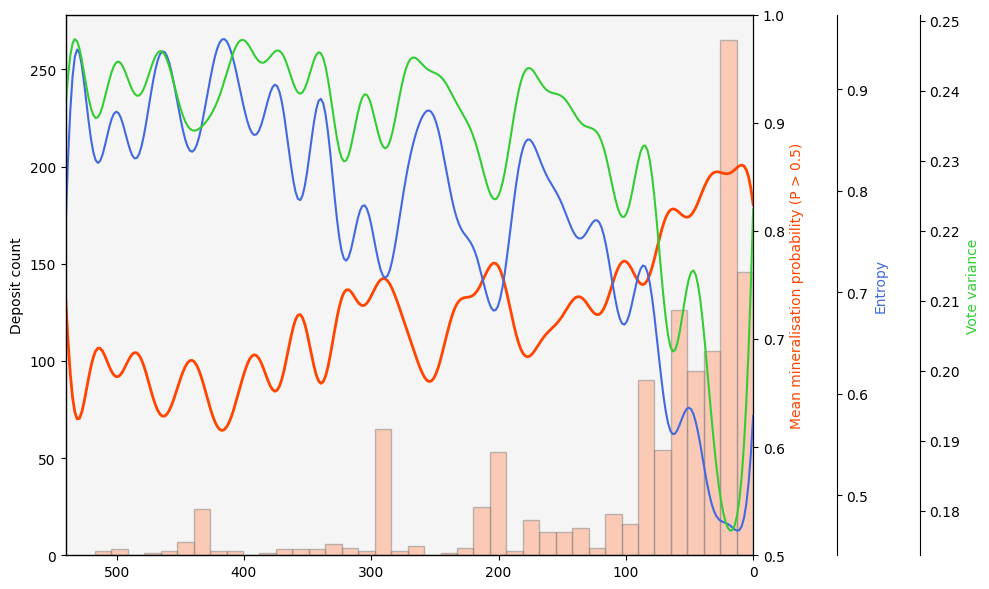

In [17]:
coastline_entropy_high_mean_age = coastline_prob_high.groupby("age (Ma)")["entropy"].mean().reset_index()
coastline_vote_var_high_mean_age = coastline_prob_high.groupby("age (Ma)")["vote_variance"].mean().reset_index()

# Sort by age to ensure correct ordering
coastline_entropy_high_mean_age = coastline_entropy_high_mean_age.sort_values("age (Ma)")
coastline_vote_var_high_mean_age = coastline_vote_var_high_mean_age.sort_values("age (Ma)")

# Define input and target
ages_high = coastline_entropy_high_mean_age["age (Ma)"].values.reshape(-1, 1)
entropies_high = coastline_entropy_high_mean_age["entropy"].values.reshape(-1, 1)
vote_vars_high = coastline_vote_var_high_mean_age["vote_variance"].values.reshape(-1, 1)

ages_high_smooth, entropies_high_smooth = smooth_curve(ages_high, entropies_high)
_, vote_vars_high_smooth = smooth_curve(ages_high, vote_vars_high)

# Set up plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_facecolor("whitesmoke")

# Plot histogram
ax1.hist(deposit_coords_recon["age (Ma)"], bins=40, orientation="vertical", color="LightSalmon", alpha=0.5, edgecolor="gray")
ax1.set_ylabel("Deposit count")

# Create secondary y-axis
ax2 = ax1.twinx()

# Plot smoothed probability line
ax2.plot(ages_high_smooth, probs_high_smooth, color="orangered", linewidth=2)
ax2.set_xlim(time_max, 0)
ax2.set_ylim(0.5, 1)
ax2.set_xlabel("Age (Ma)")
ax2.set_ylabel("Mean mineralisation probability (P > 0.5)", color="orangered")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # shift third axis to the right
ax3.plot(ages_high_smooth, entropies_high_smooth,
         linestyle="-", color="royalblue", label="Entropy")
ax3.set_ylabel("Entropy", color="royalblue")

ax4 = ax1.twinx()
ax4.spines["right"].set_position(("outward", 120))  # shift fourth axis to the right
ax4.plot(ages_high_smooth, vote_vars_high_smooth,
         linestyle="-", color="limegreen", label="Vote variance")
ax4.set_ylabel("Vote variance", color="limegreen")
    
plt.tight_layout()
plt.show()

In [18]:
if not os.path.isfile(coastline_prob_present_day_grid_filename):
    for column, filename in zip(
        ["probability", "entropy", "vote_variance"],
        [
            coastline_prob_present_day_grid_filename,
            coastline_entropy_present_day_grid_filename,
            coastline_vote_variance_present_day_grid_filename
        ]
    ):
        xmin, xmax, ymin, ymax = -180, 180, -90, 90

        # Create the grid
        grid_lons = np.arange(xmin, xmax + grid_resolution, grid_resolution)
        grid_lats = np.arange(ymin, ymax + grid_resolution, grid_resolution)
        grid_mlons, grid_mlats = np.meshgrid(grid_lons, grid_lats)

        data_lons = coastline_prob_present_day["present_lon"]
        data_lats = coastline_prob_present_day["present_lat"]
        data_values = coastline_prob_present_day[column]

        # Interpolate
        points = np.column_stack((data_lons, data_lats))
        arr = griddata(points, data_values, (grid_mlons, grid_mlats), method="nearest")  # or "linear", "cubic"

        # Mask distant grid nodes
        tree = cKDTree(points)
        flat_grid_points = np.column_stack((grid_mlons.ravel(), grid_mlats.ravel()))
        distances, _ = tree.query(flat_grid_points, k=1)

        mask = distances > grid_resolution
        arr.ravel()[mask] = np.nan  # Mask out distant nodes        

        # Create the dataset
        dset = xr.Dataset(
            data_vars={
                "z": (("lat", "lon"), arr),
            },
            coords={
                "lon": grid_lons,
                "lat": grid_lats,
            },
        )

        # Set projection info
        dset.rio.write_crs(4326, inplace=True)

        # Save as NetCDF
        dset.to_netcdf(
            filename,
            encoding={
                "z": {
                    "zlib": True,
                    "dtype": "float32",
                }
            },
        )

In [19]:
deposit_coords_recon_all = pd.read_csv(deposit_coords_recon_all_filename)
time = 0

gplot.time = time

deposit_coords_recon_t = deposit_coords_recon_all[[f"lon_{time}", f"lat_{time}", "weight"]]
deposit_coords_recon_t = deposit_coords_recon_t.dropna()
    
agegrid_filename =  f"seafloor_age_{time}Ma.nc"
agegrid_file = os.path.join(agegrid_dir, agegrid_filename)    
agegrid = gplately.grids.read_netcdf_grid(agegrid_file)

map_types = ["Probability", "Entropy", "Vote Variance"]

@interact
def show_map(map_type=map_types):
    if map_type==map_types[0]:
        raster = Raster(coastline_prob_present_day_grid_filename)
        raster.data *= 100.0
    elif map_type==map_types[1]:
        raster = Raster(coastline_entropy_present_day_grid_filename)
    elif map_type==map_types[2]:
        raster = Raster(coastline_vote_variance_present_day_grid_filename)

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_axes(
        [0.1, 0.1, 0.8, 0.8],
        projection=projection,
        facecolor=(plt.cm.colors.to_rgba("darkgray", alpha=0.5)),
    )

    cax_grd = fig.add_axes([0.1, 0.1, 0.35, 0.02])
    cax_bg = fig.add_axes([0.55, 0.1, 0.35, 0.02])

    bg = gplot.plot_grid(ax, agegrid.data, cmap=ccm.lapaz_r, vmin=0, vmax=230, alpha=0.7, zorder=1)

    gplot.plot_coastlines(ax, facecolor="darkgray", edgecolor="none", zorder=2)
    gplot.plot_plate_motion_vectors(ax, spacingX=10, spacingY=10, normalise=True, alpha=0.1, zorder=3)

    if map_type==map_types[0]:
        # grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=0, vmax=100, alpha=0.9, zorder=4)
        grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=50, vmax=100, alpha=0.9, zorder=4)
    elif map_type==map_types[1]:
        grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=0, vmax=1, alpha=0.9, zorder=4)
    elif map_type==map_types[2]:
        grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=0, vmax=0.25, alpha=0.9, zorder=4)

    gplot.plot_ridges(ax, color="dimgray", linewidth=1.5, zorder=5)
    gplot.plot_transforms(ax, color="dimgray", linewidth=1.5, zorder=5)
    gplot.plot_trenches(ax, color="k", alpha=0.3, zorder=6)
    gplot.plot_subduction_teeth(ax, spacing=0.05, color="k", alpha=0.3, zorder=7)

    sc1 = ax.scatter(
        deposit_coords_recon_t[f"lon_{time}"],
        deposit_coords_recon_t[f"lat_{time}"],
        transform=ccrs.PlateCarree(),
        marker="o",
        facecolor="yellow",
        edgecolor="black",
        s = [w * 10 for w in deposit_coords_recon_t["weight"]],
        alpha=0.3,
        zorder=8
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, linewidth=1, color="gray", alpha=0.3, linestyle="--", zorder=9)

    ax.text(0.49,-0.03, "60°E", transform=ax.transAxes, fontsize=16)
    ax.text(0.46,-0.03, "0°", transform=ax.transAxes, fontsize=16)
    ax.text(0.40,-0.025, "60°W", transform=ax.transAxes, fontsize=16)

    gl.top_labels=False
    gl.bottom_labels=False

    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}

    cbar_grd = fig.colorbar(grd, cax=cax_grd, orientation="horizontal")
    if map_type==map_types[0]:
        cbar_grd.set_label("Mineralisation Probability", fontsize=16, labelpad=10)
    elif map_type==map_types[1]:
        cbar_grd.set_label("Entropy", fontsize=16, labelpad=10)
    elif map_type==map_types[2]:
        cbar_grd.set_label("Vote Variance", fontsize=16, labelpad=10)
    cbar_grd.ax.tick_params(labelsize=16)

    cbar_bg = fig.colorbar(bg, cax=cax_bg, orientation="horizontal", extend="max")
    cbar_bg.set_label("Seafloor Age (Ma)", fontsize=16, labelpad=10)
    cbar_bg.set_ticks([0, 50, 100, 150, 200])
    cbar_bg.ax.tick_params(labelsize=16)

    # Dummy handle to trigger custom handler
    trench_handle = Line2D([], [], color="black")
    
    # Add custom handles
    custom_handles = [
        Patch(facecolor="darkgray", edgecolor="none"),
        trench_handle,
        Line2D([0], [0], color="dimgray", lw=2),
        Line2D([0], [0], marker="o", markerfacecolor="yellow", markeredgecolor="black", markersize=15, linestyle="None"),
    ]
    custom_labels = [
        "Continental Crust",
        "Trench Lines",
        "Mid-Ocean Ridges/\nTransform Faults",
        "Mineral Occurrences",
    ]

    # Draw legend
    ax.legend(custom_handles, custom_labels, fontsize=16, loc="lower left", bbox_to_anchor=(0, -0.2),
              handler_map={trench_handle: HandlerTrenchLine()})

#     ax.set_title("Global Prospectivity Map of Porphyry Mineralisation", fontsize=25, y=1.04)

    plt.show()

interactive(children=(Dropdown(description='map_type', options=('Probability', 'Entropy', 'Vote Variance'), va…

### Prediction-Area Plot

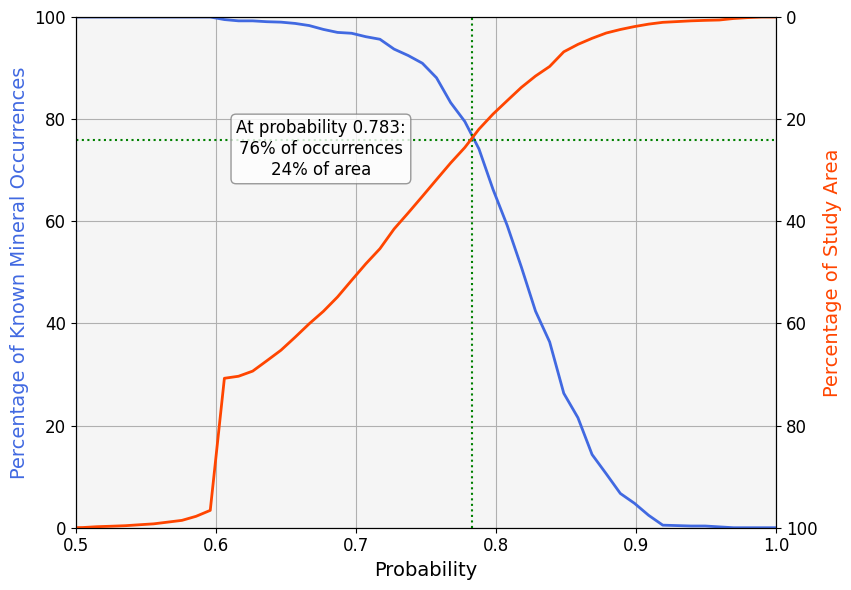

In [20]:
# Load prospectivity data
prospectivity_data = xr.open_dataset(coastline_prob_present_day_grid_filename)
prospectivity_data = prospectivity_data["z"].squeeze()

# Extract probability values at known mineral occurrence locations
occurrence_probabilities = []
for _, row in deposit_coords_recon.iterrows():
    lon, lat = row["present_lon"], row["present_lat"]
    # Extract probability value at this point
    prob_value = prospectivity_data.sel(lon=lon, lat=lat, method="nearest").item()
    occurrence_probabilities.append(prob_value)

# Convert to numpy array for easier manipulation
occurrence_probabilities = np.array(occurrence_probabilities)
occurrence_probabilities = occurrence_probabilities[~np.isnan(occurrence_probabilities)]

# Calculate total study area and number of valid cells
total_area = np.count_nonzero(~np.isnan(prospectivity_data))
total_occurrences = len(occurrence_probabilities)

# Define the probability thresholds
thresholds = np.linspace(0, 1, 100)

# Initialize lists to store results
occurrence_percentages = []
area_percentages = []

# Calculate percentages for each threshold
for threshold in thresholds:
    occurrence_percentage = np.sum(occurrence_probabilities >= threshold) / total_occurrences * 100
    area_percentage = np.sum(prospectivity_data >= threshold) / total_area * 100
    occurrence_percentages.append(occurrence_percentage)
    area_percentages.append(area_percentage)

# Convert lists to numpy arrays for plotting
occurrence_percentages = np.array(occurrence_percentages)
area_percentages = np.array(area_percentages)

# Set the font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 16

# Create the P-A plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_facecolor("whitesmoke")

# Plot the occurrence percentages
ax1.plot(thresholds, occurrence_percentages, color="royalblue", linewidth=2)
ax1.set_xlabel("Probability", fontsize=MEDIUM_SIZE)
ax1.set_ylabel("Percentage of Known Mineral Occurrences", color="royalblue", fontsize=MEDIUM_SIZE)
ax1.set_ylim(0, 100)
ax1.set_xlim(0.5, 1)
ax1.grid(True)

# Increase tick label sizes
ax1.tick_params(axis="both", labelsize=SMALL_SIZE)

# Create a second y-axis to plot the area percentages
ax2 = ax1.twinx()
ax2.plot(thresholds, area_percentages, color="orangered", linewidth=2)
ax2.set_ylabel("Percentage of Study Area", color="orangered", fontsize=MEDIUM_SIZE)
ax2.set_ylim(100, 0)  # Inverted y-axis
ax2.tick_params(axis="y", labelsize=SMALL_SIZE)

# Add horizontal and vertical lines
intersection_x = 0.783
intersection_y1 = 76
intersection_y2 = 24
h_line = ax1.hlines(y=intersection_y1, xmin=0, xmax=1, color="g", linestyles=":")
v_line = ax1.vlines(x=intersection_x, ymin=0, ymax=100, color="g", linestyles=":")

# Add annotations for the lines
# X-axis annotation
# ax1.annotate(f"{intersection_x}", xy=(intersection_x, -0.06), xycoords="data",
#              xytext=(0, -20), textcoords="offset points",
#              ha="center", va="top", color="g",
#              arrowprops=dict(arrowstyle="->", color="g"))

# # Left Y-axis (Percentage of Known Mineral Occurrences) annotation
# ax1.annotate(f"{intersection_y1}%", xy=(0, intersection_y1), xycoords="data",
#              xytext=(-25, 0), textcoords="offset points",
#              ha="right", va="center", color="g",
#              arrowprops=dict(arrowstyle="->", color="g", shrinkA=0, shrinkB=4))

# # Right Y-axis (Percentage of Study Area) annotation
# ax2.annotate(f"{intersection_y2}%", xy=(1, intersection_y2), xycoords="data",
#              xytext=(25, 0), textcoords="offset points",
#              ha="left", va="center", color="g",
#              arrowprops=dict(arrowstyle="->", color="g", shrinkA=0, shrinkB=4))

# Add a text box to explain the intersection point with larger font
ax1.annotate(f"At probability {intersection_x}:\n{intersection_y1}% of occurrences\n{intersection_y2}% of area",
             xy=(0.35, 0.8), xycoords="axes fraction",
             ha="center", va="top",
             fontsize=SMALL_SIZE,
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

# plt.title("Prediction-Area Plot")
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Adjust the plot margins to make room for annotations
plt.subplots_adjust(left=0.15, right=0.85)

plt.show()